In [1]:
import pyreadr

# cargar los datos
resultado = pyreadr.read_r('listings.Rdata')
print(resultado.keys())

odict_keys(['listings'])


In [2]:

df = resultado['listings']
print(f"Filas: {df.shape[0]}, Columnas: {df.shape[1]}")

Filas: 171748, Columnas: 80


In [3]:
df.head()

,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,...,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month,city
0,5456.0,https://www.airbnb.com/rooms/5456,2.025092e+13,2025-09-17,city scrape,"Walk to 6th, Rainey St and Convention Ctr",Great central location for walking to Convent...,My neighborhood is ideally located if you want...,https://a0.muscache.com/pictures/14084884/b5a3...,8028,...,4.73,4.79,NaN,f,1,1,0,0,3.52,"Austin, Texas"
1,6448.0,https://www.airbnb.com/rooms/6448,2.025092e+13,2025-09-17,city scrape,"Secluded Studio @ Zilker - King Bed, Bright & ...","Clean, private space with everything you need ...",The neighborhood is fun and funky (but quiet)!...,https://a0.muscache.com/pictures/airflow/Hosti...,14156,...,4.97,4.88,NaN,t,1,1,0,0,1.98,"Austin, Texas"
2,8502.0,https://www.airbnb.com/rooms/8502,2.025092e+13,2025-09-17,city scrape,Woodland Studio Lodging,Studio rental on lower level of home located i...,,https://a0.muscache.com/pictures/miso/Hosting-...,25298,...,4.69,4.63,NaN,f,1,1,0,0,0.28,"Austin, Texas"
3,13035.0,https://www.airbnb.com/rooms/13035,2.025092e+13,2025-09-17,city scrape,Historic house in highly walkable East Austin,Comfortable 2 bedroom/2 bathroom home very cen...,East Cesar Chavez is a gentrifying urban area ...,https://a0.muscache.com/pictures/miso/Hosting-...,50793,...,5.00,4.95,NaN,f,2,2,0,0,0.11,"Austin, Texas"
4,22828.0,https://www.airbnb.com/rooms/22828,2.025092e+13,2025-09-16,city scrape,Garage Apartment central SE Austin,"Fully furnished, centrally located, second sto...","wikipedia: East_Riverside-Oltorf,_Austin,_Texas",https://a0.muscache.com/pictures/miso/Hosting-...,56488,...,4.72,4.84,NaN,f,1,1,0,0,0.30,"Austin, Texas"


In [4]:
df.dtypes

id                                              float64
listing_url                                         str
scrape_id                                       float64
last_scraped                                        str
source                                              str
                                                 ...   
calculated_host_listings_count_entire_homes       int32
calculated_host_listings_count_private_rooms      int32
calculated_host_listings_count_shared_rooms       int32
reviews_per_month                               float64
city                                                str
Length: 80, dtype: object

In [6]:
nulos = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)
print(nulos[nulos > 0])  

calendar_updated                100.000000
estimated_revenue_l365d          55.605888
price                            52.041945
neighbourhood_group_cleansed     29.510096
review_scores_value              23.480914
review_scores_location           23.480914
review_scores_checkin            23.478585
review_scores_accuracy           23.471598
review_scores_communication      23.469269
review_scores_cleanliness        23.465775
reviews_per_month                23.457042
review_scores_rating             23.457042
beds                             18.449123
bathrooms                        18.280271
license                           6.132823
bedrooms                          6.097888
host_total_listings_count         0.510050
host_listings_count               0.510050
maximum_maximum_nights            0.041340
maximum_minimum_nights            0.041340
minimum_maximum_nights            0.041340
minimum_minimum_nights            0.041340
host_about                        0.000582
dtype: floa

In [7]:
print(df['calendar_updated'].value_counts(dropna=False))

calendar_updated
NaN    171748
Name: count, dtype: int64


In [8]:
print(df['price'].dtype)
print(df['price'].dropna().head(10))

str
0     $97.00
1    $160.00
2     $38.00
3    $145.00
4     $58.00
5     $49.00
6    $300.00
7    $150.00
8    $165.00
9    $117.00
Name: price, dtype: str


In [10]:
# Limpiar price: quitar $ y comas, reemplazar vacíos con NaN, luego convertir a número
import numpy as np
import pandas as pd

df['price'] = df['price'].str.replace('$', '', regex=False).str.replace(',', '', regex=False)
df['price'] = df['price'].replace('', np.nan)  # strings vacíos → NaN
df['price'] = pd.to_numeric(df['price'], errors='coerce')  # convierte, y si falla pone NaN

# Eliminar filas donde price es nulo
df = df.dropna(subset=['price'])

# Eliminar columnas que no sirven
df = df.drop(columns=['calendar_updated', 'estimated_revenue_l365d'])

# Verificar
print(f"Filas después de limpiar: {df.shape[0]}")
print(f"Columnas después de limpiar: {df.shape[1]}")
print(df['price'].describe())

Filas después de limpiar: 76246
Columnas después de limpiar: 78
count    76246.000000
mean       750.509220
std       4250.606945
min          8.000000
25%        120.000000
50%        193.000000
75%        326.000000
max      50123.000000
Name: price, dtype: float64


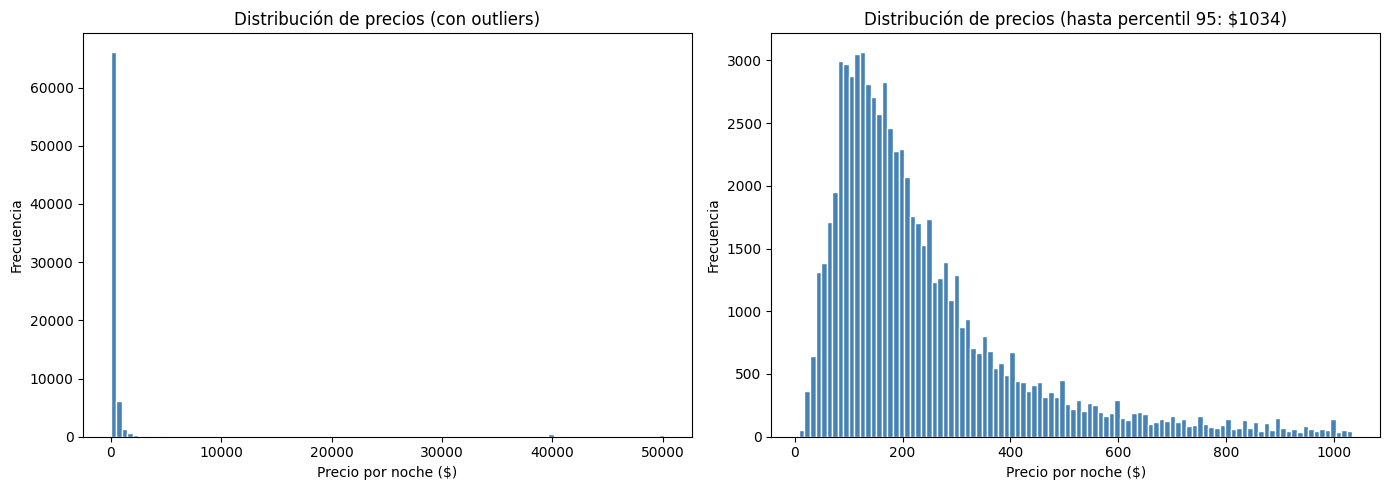

In [14]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma con todos los datos
axes[0].hist(df['price'], bins=100, color='steelblue', edgecolor='white')
axes[0].set_title('Distribución de precios (con outliers)')
axes[0].set_xlabel('Precio por noche ($)')
axes[0].set_ylabel('Frecuencia')

# Histograma sin outliers extremos (solo hasta percentil 95)
precio_95 = df['price'].quantile(0.95)
axes[1].hist(df['price'][df['price'] <= precio_95], bins=100, color='steelblue', edgecolor='white')
axes[1].set_title(f'Distribución de precios (hasta percentil 95: ${precio_95:.0f})')
axes[1].set_xlabel('Precio por noche ($)')
axes[1].set_ylabel('Frecuencia')

plt.tight_layout()
plt.show()

In [15]:
# Ver cuántas propiedades hay por ciudad
print(df['city'].value_counts())

city
Hawaii                   33132
San Diego, California    11381
Austin, Texas            10517
Chicago, Illinois         7825
Rhode Island              4993
Washington, D.C.          4892
Boston, Massachusetts     3506
Name: count, dtype: int64


In [16]:
# Precio promedio, mediano y conteo por ciudad
resumen_ciudades = df.groupby('city')['price'].agg(['mean', 'median', 'count']).round(2)
resumen_ciudades.columns = ['Precio Promedio', 'Precio Mediano', 'Cantidad']
resumen_ciudades = resumen_ciudades.sort_values('Precio Mediano', ascending=False)
print(resumen_ciudades)

                       Precio Promedio  Precio Mediano  Cantidad
city                                                            
Rhode Island                    869.70           274.0      4993
Hawaii                          945.49           233.0     33132
Boston, Massachusetts           769.98           206.0      3506
San Diego, California           650.38           176.0     11381
Chicago, Illinois               601.30           153.0      7825
Austin, Texas                   414.54           135.0     10517
Washington, D.C.                488.23           124.0      4892


In [19]:
resumen_rooms = df.groupby('room_type')['price'].agg(['mean', 'median', 'count']).round(2)
resumen_rooms.columns = ['Precio Promedio', 'Precio Mediano', 'Cantidad']
resumen_rooms = resumen_rooms.sort_values('Precio Mediano', ascending=False)
print(resumen_rooms)

                 Precio Promedio  Precio Mediano  Cantidad
room_type                                                 
Hotel room              24477.20         40000.0       649
Entire home/apt           505.12           205.0     65709
Private room              838.87            85.0      9673
Shared room               149.37            42.0       215


In [20]:
# Ver los precios de Hotel room ordenados de mayor a menor
hotel = df[df['room_type'] == 'Hotel room'][['name', 'city', 'price', 'bedrooms', 'accommodates']].sort_values('price', ascending=False)
print(hotel.head(20))

                                                     name               city  \
19752   Elegance Meets Convenience! Pet-friendly Prope...  Chicago, Illinois   
164113        Stylish Navy Yard Space | Navy Museum–0.2mi   Washington, D.C.   
5382         Prime Location! 2 Modern Units, Pet-friendly      Austin, Texas   
5044        Best Value, Quality Stay! Pool, Pets Allowed!      Austin, Texas   
5092    Explore Austin Texas! Enjoy Free Breakfast & P...      Austin, Texas   
162311                     Urban Retreat Near White House   Washington, D.C.   
56108   Spacious Room Perfect for Quiet Stay | Onsite ...             Hawaii   
56077   Enjoy Balcony View | Room Near Magic Island | ...             Hawaii   
56079     Ramada Waikiki l 2 Beds + Balcony l Family Stay             Hawaii   
56080   2 Budget-Friendly Rooms Close to Ala Moana Center             Hawaii   
56081   2 Fam-Friendly Units Near Ala Moana & Magic Is...             Hawaii   
56082   Convenient Space Perfect for Cou

In [21]:
# Eliminar las propiedades de tipo Hotel room
df = df[df['room_type'] != 'Hotel room']

# Verificar
print(f"Filas después de eliminar Hotel room: {df.shape[0]}")
print(df['room_type'].value_counts())

Filas después de eliminar Hotel room: 75597
room_type
Entire home/apt    65709
Private room        9673
Shared room          215
Name: count, dtype: int64


In [22]:
# Precio mediano según capacidad de huéspedes
resumen_accommodates = df.groupby('accommodates')['price'].agg(['median', 'count']).round(2)
resumen_accommodates.columns = ['Precio Mediano', 'Cantidad']
print(resumen_accommodates)

              Precio Mediano  Cantidad
accommodates                          
1                       54.0      2892
2                      120.0     16929
3                      127.0      4519
4                      185.0     20699
5                      190.0      3596
6                      265.0     13311
7                      260.0      1447
8                      383.0      5587
9                      333.0       572
10                     436.0      2273
11                     389.0       238
12                     562.5      1352
13                     439.0       149
14                     594.0       539
15                     565.5       166
16                     831.0      1328


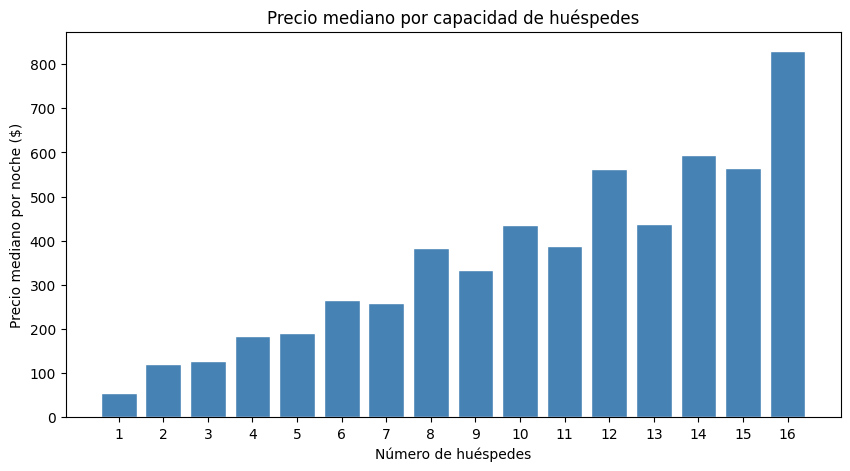

In [23]:
import matplotlib.pyplot as plt

# Precio mediano por número de huéspedes
resumen_accommodates = df.groupby('accommodates')['price'].median()

plt.figure(figsize=(10, 5))
plt.bar(resumen_accommodates.index, resumen_accommodates.values, color='steelblue', edgecolor='white')
plt.title('Precio mediano por capacidad de huéspedes')
plt.xlabel('Número de huéspedes')
plt.ylabel('Precio mediano por noche ($)')
plt.xticks(resumen_accommodates.index)
plt.show()

In [24]:
# Seleccionar solo columnas numéricas
numericas = df.select_dtypes(include=['float64', 'int32', 'int64'])

# Correlación de todas las variables numéricas con price
correlacion = numericas.corr()['price'].sort_values(ascending=False)
print(correlacion)

price                                           1.000000
calculated_host_listings_count_private_rooms    0.149373
accommodates                                    0.122458
bathrooms                                       0.115426
maximum_nights                                  0.099847
calculated_host_listings_count                  0.090151
calculated_host_listings_count_entire_homes     0.061803
host_id                                         0.033350
id                                              0.032134
review_scores_location                          0.025850
review_scores_cleanliness                       0.014935
maximum_nights_avg_ntm                         -0.003200
review_scores_rating                           -0.004663
calculated_host_listings_count_shared_rooms    -0.006818
review_scores_accuracy                         -0.020778
review_scores_checkin                          -0.022118
review_scores_communication                    -0.025843
review_scores_value            

In [25]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

# Variables relevantes para clustering 
variables_cluster = ['price', 'accommodates', 'bathrooms', 'bedrooms', 'beds']

df_cluster = df[variables_cluster].dropna().copy()

# Escalar los datos 
scaler = StandardScaler()
X = scaler.fit_transform(df_cluster)

print(f"Datos para clustering: {X.shape[0]} filas")

Datos para clustering: 75384 filas


  File "c:\Users\hugob\OneDrive\Desktop\clases\mineria_de_datos\laboratorio-4-mineria\venv\Lib\site-packages\joblib\externals\loky\backend\context.py", line 247, in _count_physical_cores
    cpu_count_physical = _count_physical_cores_win32()
  File "c:\Users\hugob\OneDrive\Desktop\clases\mineria_de_datos\laboratorio-4-mineria\venv\Lib\site-packages\joblib\externals\loky\backend\context.py", line 299, in _count_physical_cores_win32
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "C:\Users\hugob\AppData\Local\Python\pythoncore-3.14-64\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\hugob\AppData\Local\Python\pythoncore-3.14-64\Lib\subprocess.py", line 1038, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
    ~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^


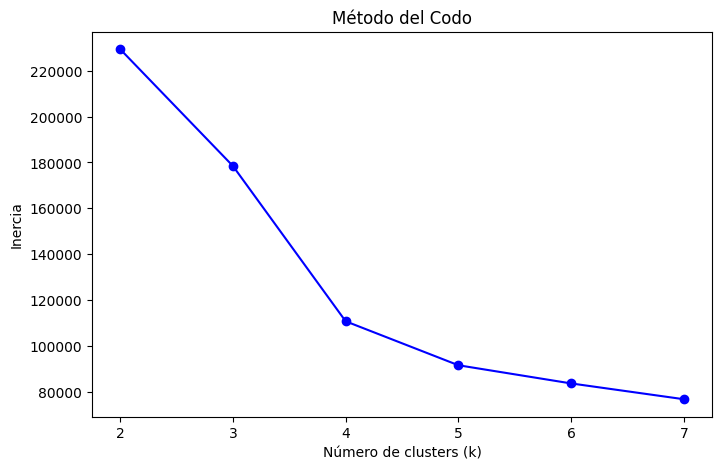

In [26]:
# Método del codo para elegir el número de clusters
inercias = []
k_values = range(2, 8)

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X)
    inercias.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(k_values, inercias, 'bo-')
plt.title('Método del Codo')
plt.xlabel('Número de clusters (k)')
plt.ylabel('Inercia')
plt.xticks(k_values)
plt.show()

In [27]:
# Aplicar KMeans con 4 clusters
kmeans = KMeans(n_clusters=4, random_state=42)
df_cluster['cluster'] = kmeans.fit_predict(X)

# Ver características de cada cluster
resumen_clusters = df_cluster.groupby('cluster').agg({
    'price': 'median',
    'accommodates': 'median',
    'bathrooms': 'median',
    'bedrooms': 'median',
    'beds': 'median',
    'cluster': 'count'
}).rename(columns={'cluster': 'cantidad'})

print(resumen_clusters)

           price  accommodates  bathrooms bedrooms beds  cantidad
cluster                                                          
0          277.0           6.0        2.0      2.0  3.0     27501
1          646.0          12.0        3.5      5.0  7.0      4658
2          140.0           3.0        1.0      1.0  1.0     42870
3        40000.0           4.0        1.0      1.0  0.0       355


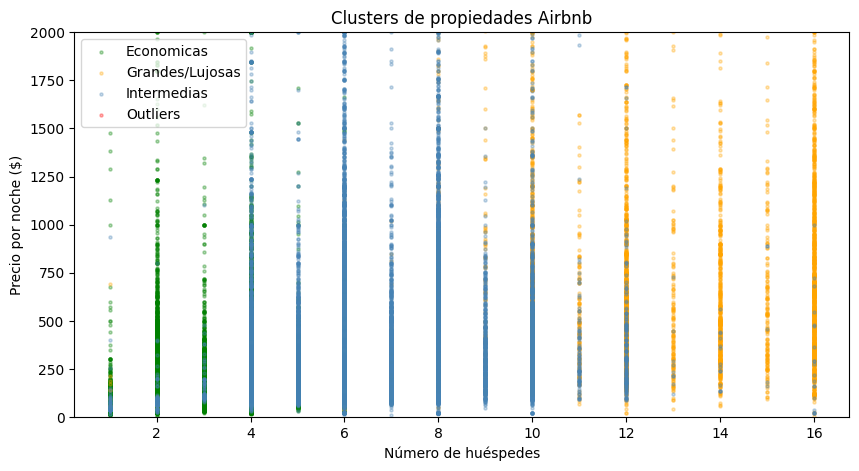

In [28]:
# Asignar nombres descriptivos a cada cluster
nombres_clusters = {
    0: 'Intermedias',
    1: 'Grandes/Lujosas',
    2: 'Economicas',
    3: 'Outliers'
}

df_cluster['cluster_nombre'] = df_cluster['cluster'].map(nombres_clusters)

# Visualizar los clusters por precio
plt.figure(figsize=(10, 5))
colores = {'Economicas': 'green', 'Intermedias': 'steelblue', 
           'Grandes/Lujosas': 'orange', 'Outliers': 'red'}

for nombre, grupo in df_cluster.groupby('cluster_nombre'):
    plt.scatter(grupo['accommodates'], grupo['price'], 
                label=nombre, alpha=0.3, s=5, 
                color=colores[nombre])

plt.ylim(0, 2000)  # Limitamos para ver mejor
plt.title('Clusters de propiedades Airbnb')
plt.xlabel('Número de huéspedes')
plt.ylabel('Precio por noche ($)')
plt.legend()
plt.show()

In [29]:
# Seleccionar variables útiles para predecir el precio
variables = ['price', 'accommodates', 'bathrooms', 'bedrooms', 
             'beds', 'minimum_nights', 'room_type', 'city']

# Crear un dataframe solo con esas variables
df_modelo = df[variables].copy()

# Eliminar filas con nulos en esas variables
df_modelo = df_modelo.dropna()

print(f"Filas disponibles para modelar: {df_modelo.shape[0]}")
print(f"\nValores nulos restantes:\n{df_modelo.isnull().sum()}")

Filas disponibles para modelar: 75384

Valores nulos restantes:
price             0
accommodates      0
bathrooms         0
bedrooms          0
beds              0
minimum_nights    0
room_type         0
city              0
dtype: int64


In [30]:
# Convertir room_type y city a variables numéricas 0 o 1
df_modelo = pd.get_dummies(df_modelo, columns=['room_type', 'city'], drop_first=True)

print(f"Columnas después de convertir: {df_modelo.shape[1]}")
print(df_modelo.columns.tolist())

Columnas después de convertir: 14
['price', 'accommodates', 'bathrooms', 'bedrooms', 'beds', 'minimum_nights', 'room_type_Private room', 'room_type_Shared room', 'city_Boston, Massachusetts', 'city_Chicago, Illinois', 'city_Hawaii', 'city_Rhode Island', 'city_San Diego, California', 'city_Washington, D.C.']


In [31]:
from sklearn.model_selection import train_test_split
variables = ['price', 'accommodates', 'bathrooms', 'bedrooms', 
             'beds', 'minimum_nights', 'room_type', 'city']

df_modelo = df[variables].dropna().copy()

# Separar X e y
y = df_modelo.pop('price')  
X = df_modelo

# División 70/30 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, train_size=0.7)

print(f"Entrenamiento: {X_train.shape}")
print(f"Prueba:        {X_test.shape}")

Entrenamiento: (52768, 7)
Prueba:        (22616, 7)


In [32]:
from sklearn.compose import make_column_selector as selector
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import GridSearchCV
import numpy as np

# Separar columnas numéricas de categóricas
numerical_columns = selector(dtype_exclude=object)(X)
categorical_columns = selector(dtype_include=object)(X)

print("Variables numéricas:", numerical_columns)
print("Variables categóricas:", categorical_columns)

# Preprocesador: OneHotEncoder para las categóricas
categorical_preprocessor = OneHotEncoder(handle_unknown="ignore")
preprocessor = ColumnTransformer([
    ('one-hot-encoder', categorical_preprocessor, categorical_columns)
])

Variables numéricas: ['accommodates', 'bathrooms', 'minimum_nights']
Variables categóricas: ['bedrooms', 'beds', 'room_type', 'city']


In [33]:
# Ver qué tipo de dato son y cómo lucen
print("Tipo bedrooms:", X_train['bedrooms'].dtype)
print("Tipo beds:", X_train['beds'].dtype)
print()
print("Primeros valores bedrooms:")
print(X_train['bedrooms'].value_counts().head(10))

Tipo bedrooms: object
Tipo beds: object

Primeros valores bedrooms:
bedrooms
1    21835
2    14235
3     7045
0     4600
4     3071
5     1070
6      542
7      141
8       94
9       51
Name: count, dtype: int64


In [34]:
X_train = X_train.copy()
X_test = X_test.copy()

X_train['bedrooms'] = pd.to_numeric(X_train['bedrooms'], errors='coerce')
X_train['beds'] = pd.to_numeric(X_train['beds'], errors='coerce')
X_test['bedrooms'] = pd.to_numeric(X_test['bedrooms'], errors='coerce')
X_test['beds'] = pd.to_numeric(X_test['beds'], errors='coerce')

# Verificar que quedaron como numéricas
numerical_columns = selector(dtype_exclude=object)(X_train)
categorical_columns = selector(dtype_include=object)(X_train)

print("Variables numéricas:", numerical_columns)
print("Variables categóricas:", categorical_columns)

Variables numéricas: ['accommodates', 'bathrooms', 'bedrooms', 'beds', 'minimum_nights']
Variables categóricas: ['room_type', 'city']
